# Confusion matrices

Where each spam filter goes wrong on the 18,514 unique emails from the experiment described in the
[README](../README.md). An email counts as spam when its score is at or above `CUTOFF` (0.5 in the
README; change it below to see how the matrices shift).

The scores come from `results/tfidf_oof.jsonl`, written by `tfidf_baseline.py`. It has one row per
unique email with every approach's score, so this notebook needs neither the dataset nor an API key.

In [1]:
import json
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize, to_rgb
from matplotlib.patches import Rectangle

CUTOFF = 0.5  # an email counts as spam when its score is at least this

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent
rows = [json.loads(line) for line in (ROOT / "results" / "tfidf_oof.jsonl").open()]
is_spam = np.array([row["label"] == "spam" for row in rows])

# README name -> (column in tfidf_oof.jsonl, labeled emails used)
APPROACHES = {
    "TypeSafe, plain question": ("TypeSafe: bare question (0 labels)", "0 labeled emails"),
    "TypeSafe, detailed criteria": ("TypeSafe: structured criteria (0 labels)", "0 labeled emails"),
    "TF-IDF logistic regression": ("TF-IDF logreg, grouped CV (~14.8K labels)", "~14.8K labeled emails"),
    "TF-IDF naive Bayes": ("TF-IDF naive Bayes, grouped CV", "~14.8K labeled emails"),
    "Average of detailed criteria and logistic regression": (
        "Average of structured criteria + logreg", "~14.8K labeled emails"),
}
scores = {name: np.array([row[column] for row in rows]) for name, (column, _) in APPROACHES.items()}
print(f"{len(rows):,} emails: {(~is_spam).sum():,} ham, {is_spam.sum():,} spam")

18,514 emails: 10,415 ham, 8,099 spam


## Counts

Rows are the true label and columns the prediction. Percentages are shares of the true label: of
all ham, or of all spam.

In [2]:
def confusion(score):
    """2x2 counts: rows are the true label (ham, spam), columns the prediction (ham, spam)."""
    predicted_spam = score >= CUTOFF
    return np.array([
        [np.sum(~is_spam & ~predicted_spam), np.sum(~is_spam & predicted_spam)],
        [np.sum(is_spam & ~predicted_spam), np.sum(is_spam & predicted_spam)],
    ])


matrices = {name: confusion(score) for name, score in scores.items()}

table = [
    "| Approach | Correct ham | Ham flagged as spam | Missed spam | Correct spam | Accuracy |",
    "|---|---|---|---|---|---|",
]
for name, m in matrices.items():
    table.append(
        f"| {name} | {m[0, 0]:,} | {m[0, 1]:,} ({m[0, 1] / m[0].sum():.2%}) "
        f"| {m[1, 0]:,} ({m[1, 0] / m[1].sum():.2%}) | {m[1, 1]:,} | {np.trace(m) / m.sum():.2%} |"
    )
display(Markdown("\n".join(table)))

| Approach | Correct ham | Ham flagged as spam | Missed spam | Correct spam | Accuracy |
|---|---|---|---|---|---|
| TypeSafe, plain question | 9,721 | 694 (6.66%) | 54 (0.67%) | 8,045 | 95.96% |
| TypeSafe, detailed criteria | 10,212 | 203 (1.95%) | 106 (1.31%) | 7,993 | 98.33% |
| TF-IDF logistic regression | 10,265 | 150 (1.44%) | 149 (1.84%) | 7,950 | 98.39% |
| TF-IDF naive Bayes | 10,240 | 175 (1.68%) | 367 (4.53%) | 7,732 | 97.07% |
| Average of detailed criteria and logistic regression | 10,340 | 75 (0.72%) | 69 (0.85%) | 8,030 | 99.22% |

## Where the two best approaches disagree

TypeSafe with detailed criteria against TF-IDF logistic regression, split by the true label.

In [3]:
typesafe_says_spam = scores["TypeSafe, detailed criteria"] >= CUTOFF
logreg_says_spam = scores["TF-IDF logistic regression"] >= CUTOFF

agreement = {}  # true label -> 2x2 counts; rows TypeSafe's call (ham, spam), columns logreg's call
for label, true_spam in (("Actual ham", False), ("Actual spam", True)):
    in_class = is_spam == true_spam
    agreement[label] = np.array([
        [np.sum(in_class & (typesafe_says_spam == ts) & (logreg_says_spam == lr)) for lr in (False, True)]
        for ts in (False, True)
    ])

typesafe_right = typesafe_says_spam == is_spam
logreg_right = logreg_says_spam == is_spam
print(f"both right:          {np.sum(typesafe_right & logreg_right):,}")
print(f"only TypeSafe right: {np.sum(typesafe_right & ~logreg_right):,}")
print(f"only logreg right:   {np.sum(~typesafe_right & logreg_right):,}")
print(f"both wrong:          {np.sum(~typesafe_right & ~logreg_right):,}")

both right:          17,977
only TypeSafe right: 228
only logreg right:   238
both wrong:          71


## Heatmaps

Only mistakes are colored, all on one blue scale shared by every matrix, so a darker cell always
means more wrong emails. Correct predictions are gray.

In [4]:
RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
        "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
NEUTRAL, INK, INK_2, SURFACE = "#f0efec", "#0b0b0b", "#52514e", "#fcfcfb"
MISTAKES = LinearSegmentedColormap.from_list("mistakes", RAMP)

mistake_counts = [m[0, 1] for m in matrices.values()] + [m[1, 0] for m in matrices.values()]
mistake_counts += [m[r, c] for m in agreement.values() for r in range(2) for c in range(2)
                   if not (m is agreement["Actual ham"] and r == c == 0)
                   and not (m is agreement["Actual spam"] and r == c == 1)]
NORM = Normalize(0, np.ceil(max(mistake_counts) / 100) * 100)


def luminance(color):
    channels = [c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4 for c in to_rgb(color)]
    return 0.2126 * channels[0] + 0.7152 * channels[1] + 0.0722 * channels[2]


def ink_on(fill):
    """White or near-black text, whichever contrasts more with the fill."""
    white = 1.05 / (luminance(fill) + 0.05)
    dark = (luminance(fill) + 0.05) / (luminance(INK) + 0.05)
    return "white" if white > dark else INK


def draw_matrix(ax, counts, correct, row_labels, col_labels, notes, title):
    gap = 0.025
    for r in range(2):
        for c in range(2):
            fill = NEUTRAL if correct[r][c] else MISTAKES(NORM(counts[r, c]))
            ax.add_patch(Rectangle((c + gap, r + gap), 1 - 2 * gap, 1 - 2 * gap, facecolor=fill, edgecolor="none"))
            color = INK if correct[r][c] else ink_on(fill)
            ax.text(c + 0.08, r + 0.42, f"{counts[r, c]:,}", fontsize=15, fontweight="bold", color=color, va="center")
            ax.text(c + 0.08, r + 0.7, notes[r][c], fontsize=9, color=color, va="center")
    ax.set_xlim(0, 2)
    ax.set_ylim(2, 0)
    ax.set_xticks([0.5, 1.5], col_labels)
    ax.set_yticks([0.5, 1.5], row_labels)
    ax.xaxis.tick_top()
    ax.tick_params(length=0, labelsize=9, labelcolor=INK_2)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_title(title, loc="left", fontsize=10.5, color=INK, pad=28)


def add_scale_key(ax):
    ax.axis("off")
    bar = ax.inset_axes([0.05, 0.55, 0.85, 0.08])
    colorbar = plt.colorbar(ScalarMappable(NORM, MISTAKES), cax=bar, orientation="horizontal")
    colorbar.outline.set_visible(False)
    colorbar.ax.tick_params(labelsize=9, labelcolor=INK_2, length=3, color=INK_2)
    ax.text(0.05, 0.72, "Mistakes (emails)", fontsize=10, color=INK, transform=ax.transAxes)
    ax.add_patch(Rectangle((0.05, 0.25), 0.08, 0.06, facecolor=NEUTRAL, edgecolor="none", transform=ax.transAxes))
    ax.text(0.16, 0.28, "Correct predictions", fontsize=10, color=INK, va="center", transform=ax.transAxes)

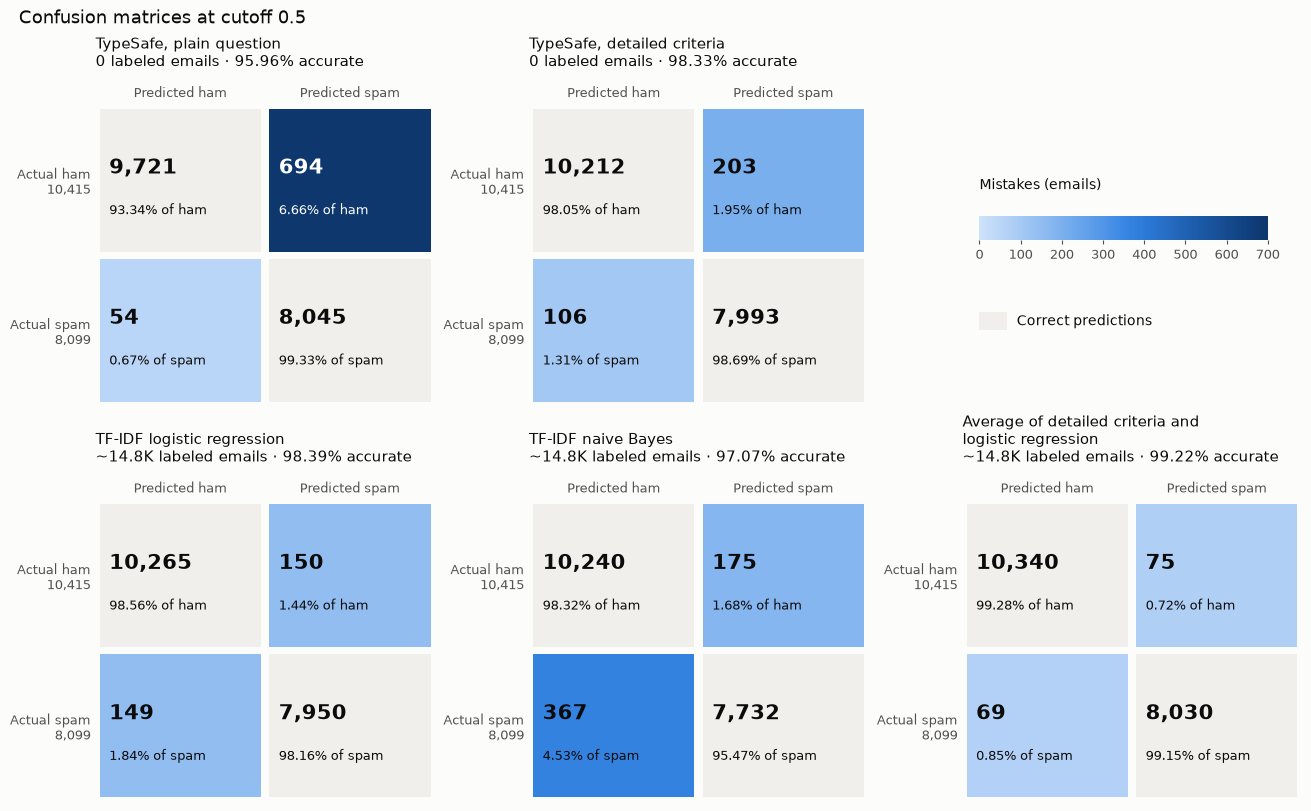

In [5]:
n_ham, n_spam = int((~is_spam).sum()), int(is_spam.sum())
fig, axes = plt.subplots(2, 3, figsize=(13, 8), facecolor=SURFACE, layout="constrained")
slots = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1], axes[1, 2]]
for ax, (name, m) in zip(slots, matrices.items()):
    ax.set_facecolor(SURFACE)
    notes = [[f"{m[0, 0] / n_ham:.2%} of ham", f"{m[0, 1] / n_ham:.2%} of ham"],
             [f"{m[1, 0] / n_spam:.2%} of spam", f"{m[1, 1] / n_spam:.2%} of spam"]]
    title = f"{textwrap.fill(name, 34)}\n{APPROACHES[name][1]} · {np.trace(m) / m.sum():.2%} accurate"
    draw_matrix(ax, m, [[True, False], [False, True]], [f"Actual ham\n{n_ham:,}", f"Actual spam\n{n_spam:,}"],
                ["Predicted ham", "Predicted spam"], notes, title)
add_scale_key(axes[0, 2])
fig.suptitle(f"Confusion matrices at cutoff {CUTOFF}", x=0.01, ha="left", fontsize=13, color=INK)
plt.show()

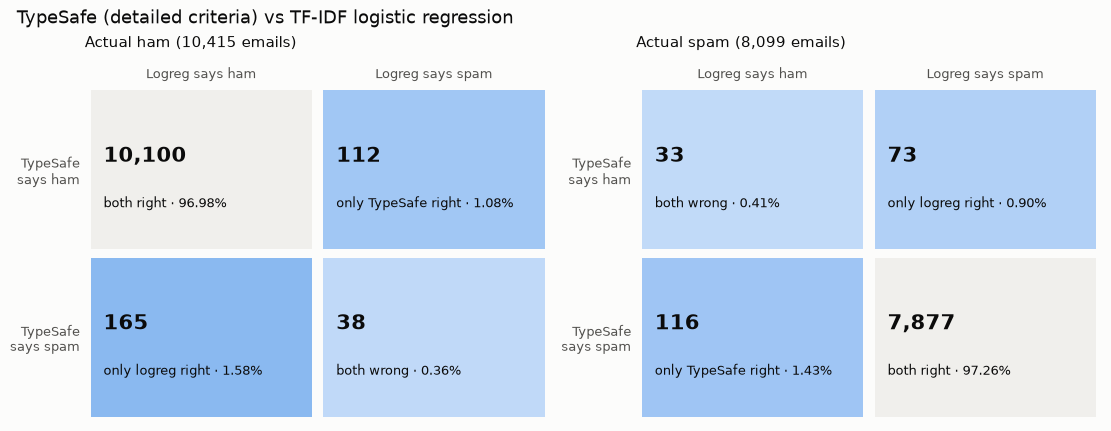

In [6]:
def kind(typesafe_ok, logreg_ok):
    if typesafe_ok and logreg_ok:
        return "both right"
    if typesafe_ok:
        return "only TypeSafe right"
    return "only logreg right" if logreg_ok else "both wrong"


fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), facecolor=SURFACE, layout="constrained")
for ax, (label, m) in zip(axes, agreement.items()):
    ax.set_facecolor(SURFACE)
    right = 1 if label == "Actual spam" else 0  # index of the correct call
    total = m.sum()
    notes = [[f"{kind(r == right, c == right)} · {m[r, c] / total:.2%}" for c in range(2)] for r in range(2)]
    correct = [[r == right and c == right for c in range(2)] for r in range(2)]
    draw_matrix(ax, m, correct, ["TypeSafe\nsays ham", "TypeSafe\nsays spam"],
                ["Logreg says ham", "Logreg says spam"], notes, f"{label} ({total:,} emails)")
fig.suptitle("TypeSafe (detailed criteria) vs TF-IDF logistic regression", x=0.01, ha="left", fontsize=13, color=INK)
plt.show()